In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display
import warnings

import ast

warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 전역 시드 설정 (재현성을 위해)
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [2]:
# 프로모션 데이터 불러오기 (새로 추가된 코드)
promotion = pd.read_csv('../data/promotion_df_final.csv')
merged = pd.read_csv('../data/all_merged.csv')


# 고객 세그먼트별 전환/이탈률 보기

“우리는 단순히 이벤트가 있었는지를 세는 게 아니라,
오퍼 퍼널의 순서가 맞는지까지 확인해서 전환율을 계산하고 있다.
그래서 viewed_flag는 received <= viewed, completed_after_view_flag는 viewed <= completed로 정의해야 한다.
이렇게 해야 열람률과 완료율이 실제 퍼널 의미에 맞게 계산된다.”

In [3]:
# 세그먼트 분석용 데이터 복사 (bogo랑 discount만!)
seg_df = promotion[promotion['offer_type'].isin(['bogo', 'discount'])].copy()

# 공통 플래그 만들기
seg_df['viewed_flag'] = ((seg_df['offer received'] <= seg_df['offer viewed'])).astype(int)
seg_df['completed_after_view_flag'] = ((seg_df['offer viewed'] <= seg_df['offer completed'])).astype(int)

# 02 파일과 컬럼 일치를 위한 flow_type 기반 파생 플래그 추가
# flow_type: 1=정상(받기->보기->완료), 2=바로완료(보기 없이 완료), 0=비정상, 3=보기만
seg_df['is_normal_flow'] = (seg_df['flow_type'] == 1).astype(int)
seg_df['is_normal_viewed'] = (seg_df['flow_type'].isin([1, 3])).astype(int)  # 정상 열람 (보기 포함)
seg_df['is_direct_complete'] = (seg_df['flow_type'] == 2).astype(int)        # 바로완료
seg_df['is_invalid'] = (seg_df['flow_type'] == 0).astype(int)                # 비정상


In [4]:
seg_df

,person,offer_id,offer_cycle,offer received,offer viewed,offer completed,offer_type,difficulty,reward,duration,...,is_normal_flow,is_deduplicated,flow_type,amount_from_received,amount_from_viewed,viewed_flag,completed_after_view_flag,is_normal_viewed,is_direct_complete,is_invalid
0,0009655768c64bdeb2e877511632db8f,bogo_5_5_5,Bogo_1,408.0,456.0,414.0,bogo,5,5,5,...,0,1,0,8.57,0.00,1,0,0,0,1
1,0009655768c64bdeb2e877511632db8f,discount_10_2_10,Discount_1,504.0,540.0,528.0,discount,10,2,10,...,0,1,0,14.11,0.00,1,0,0,0,1
2,0009655768c64bdeb2e877511632db8f,discount_10_2_7,Discount_1,576.0,NaN,576.0,discount,10,2,7,...,0,1,2,10.27,0.00,0,0,0,1,0
3,0011e0d4e6b944f998e987f904e8c1e5,discount_7_3_7,Discount_1,168.0,186.0,252.0,discount,7,3,7,...,1,1,1,11.93,11.93,1,1,1,0,0
4,0011e0d4e6b944f998e987f904e8c1e5,bogo_5_5_7,Bogo_1,504.0,516.0,576.0,bogo,5,5,7,...,1,1,1,22.05,22.05,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76266,ffc77312ccda49fca19506f1cdf44923,bogo_5_5_7,Bogo_1,168.0,NaN,NaN,bogo,5,5,7,...,0,1,4,0.00,0.00,0,0,0,0,0
76267,ffc77312ccda49fca19506f1cdf44923,discount_7_3_7,Discount_1,336.0,NaN,NaN,discount,7,3,7,...,0,1,4,0.00,0.00,0,0,0,0,0
76271,ffe5257abf8840b395e1ee6b29894637,discount_20_5_10,Discount_2,504.0,NaN,NaN,discount,20,5,10,...,0,1,4,0.00,0.00,0,0,0,0,0
76273,ffede3b700ac41d6a266fa1ba74b4f16,discount_20_5_10,Discount_1,504.0,NaN,NaN,discount,20,5,10,...,0,1,4,0.00,0.00,0,0,0,0,0


In [5]:
seg_df["age"].isna().sum()

np.int64(0)

In [6]:
seg_df.columns

Index(['person', 'offer_id', 'offer_cycle', 'offer received', 'offer viewed',
       'offer completed', 'offer_type', 'difficulty', 'reward', 'duration',
       'web', 'email', 'mobile', 'social', 'gender', 'age', 'became_member_on',
       'income', 'amount', 'is_received', 'is_viewed', 'is_completed',
       'is_normal_flow', 'is_deduplicated', 'flow_type',
       'amount_from_received', 'amount_from_viewed', 'viewed_flag',
       'completed_after_view_flag', 'is_normal_viewed', 'is_direct_complete',
       'is_invalid'],
      dtype='str')

| flow_type | 흐름 설명                     | 비고            |
|-----------|------------------------------|-----------------|
| 0         | 받기 → 완료 → 보기            | 비정상 흐름      |
| 1         | 받기 → 보기 → 완료            | 정상 흐름        |
| 2         | 받기 → NaN -> 완료                   | 바로 완료   |
| 3         | 받기 → 보기 -> NaN                   | 완료 없이 보기   |
| 4         | 받기 -> NaN -> NaN                        | 반응 없음        |

<br>

| 지표     | 분자                                   | 분모                                   |
|----------|----------------------------------------|----------------------------------------|
| 열람율   | flow_type.isin([1,3])의 is_viewed       | flow_type.isin([0,1,2,3,4])의 count      |
| 전환율   | flow_type.isin([1,3])의 is_completed    | flow_type.isin([0,1,2,3,4])의 count      |
| 단계별전환율 | flow_type.isin([1])의 is_completed | flow_type.isin([1,3])의 count |
| 완료율   | flow_type.isin([0,1,2,3,4])의 is_completed | flow_type.isin([0,1,2,3,4])의 count |
| 정상흐름비중 | flow_type == 1의 count | flow_type.isin([0,1,2,3,4])의 count |
| 비정상흐름비중 | flow_type == 0의 count | flow_type.isin([0,1,2,3,4])의 count |
| 바로완료비중 | flow_type == 2의 count | flow_type.isin([0,1,2,3,4])의 count |

# bogo + discount 전체에 대한 비율 먼저 확인

In [7]:
gender_summary = seg_df.groupby('gender').agg(
    total_received=('person', 'count'),
    total_viewed=('viewed_flag', 'sum'),
    total_completed=('completed_after_view_flag', 'sum'),
    normal_flow=('is_normal_flow', 'sum'),
    normal_viewed=('is_normal_viewed', 'sum'),
    direct_complete=('is_direct_complete', 'sum'),
    invalid_flow=('is_invalid', 'sum')
).reset_index()

gender_summary['열람율(%)']        = (gender_summary['total_viewed'] / gender_summary['total_received'] * 100).round(2)
gender_summary['정상열람율(%)']    = (gender_summary['normal_viewed'] / gender_summary['total_received'] * 100).round(2)
gender_summary['단계별전환율(%)']  = (gender_summary['normal_flow'] / gender_summary['normal_viewed'] * 100).round(2)
gender_summary['정상흐름비중(%)']  = (gender_summary['normal_flow'] / gender_summary['total_received'] * 100).round(2)
gender_summary['비정상흐름비중(%)'] = (gender_summary['invalid_flow'] / gender_summary['total_received'] * 100).round(2)
gender_summary['바로완료비중(%)']  = (gender_summary['direct_complete'] / gender_summary['total_received'] * 100).round(2)
gender_summary['완료율(%)']        = (gender_summary['total_completed'] / gender_summary['total_received'] * 100).round(2)

cols = ['gender', 'total_received', 'total_viewed', 'total_completed', 'normal_flow',
        '열람율(%)', '정상열람율(%)', '단계별전환율(%)',
        '정상흐름비중(%)', '비정상흐름비중(%)', '바로완료비중(%)', '완료율(%)']
display(gender_summary[['gender', 'total_received', 'total_viewed', 'total_completed', 'normal_flow', '열람율(%)', '정상열람율(%)', '단계별전환율(%)', '정상흐름비중(%)', '비정상흐름비중(%)', '바로완료비중(%)', '완료율(%)']]
    .sort_values('total_received', ascending=False))

,gender,total_received,total_viewed,total_completed,normal_flow,열람율(%),정상열람율(%),단계별전환율(%),정상흐름비중(%),비정상흐름비중(%),바로완료비중(%),완료율(%)
1,M,30562,23012,11522,11522,75.30,68.65,54.92,37.70,6.65,8.69,37.70
0,F,21918,16876,10426,10426,77.00,67.59,70.37,47.57,9.40,12.82,47.57
2,O,721,612,386,386,84.88,76.56,69.93,53.54,8.32,6.52,53.54


In [8]:
seg_df['age_group'] = pd.cut(
    seg_df['age'],
    bins=[0, 20, 30, 40, 50, 60, 70, 120],
    labels=['10s', '20s', '30s', '40s', '50s', '60s', '70+'],
    right=False
)
seg_df['age_group'] = seg_df['age_group'].astype('object').fillna('Unknown')

age_summary = seg_df.groupby('age_group').agg(
    total_received=('person', 'count'),
    total_viewed=('viewed_flag', 'sum'),
    total_completed=('completed_after_view_flag', 'sum'),
    normal_flow=('is_normal_flow', 'sum'),
    normal_viewed=('is_normal_viewed', 'sum'),
    direct_complete=('is_direct_complete', 'sum'),
    invalid_flow=('is_invalid', 'sum')
).reset_index()

age_summary['열람율(%)']        = (age_summary['total_viewed'] / age_summary['total_received'] * 100).round(2)
age_summary['정상열람율(%)']    = (age_summary['normal_viewed'] / age_summary['total_received'] * 100).round(2)
age_summary['단계별전환율(%)']  = (age_summary['normal_flow'] / age_summary['normal_viewed'] * 100).round(2)
age_summary['정상흐름비중(%)']  = (age_summary['normal_flow'] / age_summary['total_received'] * 100).round(2)
age_summary['비정상흐름비중(%)'] = (age_summary['invalid_flow'] / age_summary['total_received'] * 100).round(2)
age_summary['바로완료비중(%)']  = (age_summary['direct_complete'] / age_summary['total_received'] * 100).round(2)
age_summary['완료율(%)']        = (age_summary['total_completed'] / age_summary['total_received'] * 100).round(2)

cols = ['age_group', 'total_received', 'total_viewed', 'total_completed', 'normal_flow',
        '열람율(%)', '정상열람율(%)', '단계별전환율(%)',
        '정상흐름비중(%)', '비정상흐름비중(%)', '바로완료비중(%)', '완료율(%)']
display(age_summary[['age_group', 'total_received', 'total_viewed', 'total_completed', 'normal_flow', '열람율(%)', '정상열람율(%)', '단계별전환율(%)', '정상흐름비중(%)', '비정상흐름비중(%)', '바로완료비중(%)', '완료율(%)']])

,age_group,total_received,total_viewed,total_completed,normal_flow,열람율(%),정상열람율(%),단계별전환율(%),정상흐름비중(%),비정상흐름비중(%),바로완료비중(%),완료율(%)
0,10s,722,512,204,204,70.91,64.13,44.06,28.25,6.79,8.59,28.25
1,20s,4997,3512,1557,1557,70.28,64.12,48.60,31.16,6.16,9.65,31.16
2,30s,5515,4039,2093,2093,73.24,66.58,57.00,37.95,6.65,9.07,37.95
3,40s,8241,6561,3600,3600,79.61,72.70,60.09,43.68,6.92,7.50,43.68
4,50s,12692,9704,5629,5629,76.46,68.04,65.18,44.35,8.41,11.53,44.35
5,60s,10780,8330,4710,4710,77.27,68.74,63.56,43.69,8.53,11.09,43.69
6,70+,18095,14236,5474,5474,78.67,73.57,41.12,30.25,5.10,7.22,30.25


In [9]:
seg_df['income_group'] = pd.cut(
    seg_df['income'],
    bins=[0, 40000, 60000, 80000, 100000, float('inf')],
    labels=['0-40k', '40-60k', '60-80k', '80-100k', '100k+'],
    right=False
)
seg_df['income_group'] = seg_df['income_group'].astype('object').fillna('Unknown')

income_summary = seg_df.groupby('income_group').agg(
    total_received=('person', 'count'),
    total_viewed=('viewed_flag', 'sum'),
    total_completed=('completed_after_view_flag', 'sum'),
    normal_flow=('is_normal_flow', 'sum'),
    normal_viewed=('is_normal_viewed', 'sum'),
    direct_complete=('is_direct_complete', 'sum'),
    invalid_flow=('is_invalid', 'sum')
).reset_index()

income_summary['열람율(%)']        = (income_summary['total_viewed'] / income_summary['total_received'] * 100).round(2)
income_summary['정상열람율(%)']    = (income_summary['normal_viewed'] / income_summary['total_received'] * 100).round(2)
income_summary['단계별전환율(%)']  = (income_summary['normal_flow'] / income_summary['normal_viewed'] * 100).round(2)
income_summary['정상흐름비중(%)']  = (income_summary['normal_flow'] / income_summary['total_received'] * 100).round(2)
income_summary['비정상흐름비중(%)'] = (income_summary['invalid_flow'] / income_summary['total_received'] * 100).round(2)
income_summary['바로완료비중(%)']  = (income_summary['direct_complete'] / income_summary['total_received'] * 100).round(2)
income_summary['완료율(%)']        = (income_summary['total_completed'] / income_summary['total_received'] * 100).round(2)

cols = ['income_group', 'total_received', 'total_viewed', 'total_completed', 'normal_flow',
        '열람율(%)', '정상열람율(%)', '단계별전환율(%)',
        '정상흐름비중(%)', '비정상흐름비중(%)', '바로완료비중(%)', '완료율(%)']
display(income_summary[['income_group', 'total_received', 'total_viewed', 'total_completed', 'normal_flow', '열람율(%)', '정상열람율(%)', '단계별전환율(%)', '정상흐름비중(%)', '비정상흐름비중(%)', '바로완료비중(%)', '완료율(%)']]
    .sort_values('total_received', ascending=False))

,income_group,total_received,total_viewed,total_completed,normal_flow,열람율(%),정상열람율(%),단계별전환율(%),정상흐름비중(%),비정상흐름비중(%),바로완료비중(%),완료율(%)
3,60-80k,16712,13084,7530,7530,78.29,70.03,64.34,45.06,8.26,9.75,45.06
2,40-60k,16101,12083,6000,6000,75.05,68.73,54.22,37.26,6.31,8.50,37.26
4,80-100k,9364,7645,4900,4900,81.64,70.89,73.82,52.33,10.75,12.22,52.33
5,Unknown,7841,6394,933,933,81.55,80.87,14.71,11.90,0.68,1.47,11.90
0,0-40k,7072,4941,2076,2076,69.87,64.93,45.21,29.36,4.93,8.14,29.36
1,100k+,3952,2747,1828,1828,69.51,59.39,77.89,46.26,10.12,20.14,46.26


비율적 차이가 있는지 보려면 z비율

# 이후 Offer_type별 비교

In [29]:
offer_type_gender = seg_df.groupby(['offer_type', 'gender']).agg(
    total_received=('person', 'count'),
    total_viewed=('viewed_flag', 'sum'),
    total_completed=('completed_after_view_flag', 'sum'),
    normal_flow=('is_normal_flow', 'sum'),
    normal_viewed=('is_normal_viewed', 'sum'),
    direct_complete=('is_direct_complete', 'sum'),
    invalid_flow=('is_invalid', 'sum')
).reset_index()

offer_type_gender['열람율(%)']        = (offer_type_gender['total_viewed'] / offer_type_gender['total_received'] * 100).round(2)
offer_type_gender['정상열람율(%)']    = (offer_type_gender['normal_viewed'] / offer_type_gender['total_received'] * 100).round(2)
offer_type_gender['단계별전환율(%)']  = (offer_type_gender['normal_flow'] / offer_type_gender['normal_viewed'] * 100).round(2)
offer_type_gender['정상흐름비중(%)']  = (offer_type_gender['normal_flow'] / offer_type_gender['total_received'] * 100).round(2)
offer_type_gender['비정상흐름비중(%)'] = (offer_type_gender['invalid_flow'] / offer_type_gender['total_received'] * 100).round(2)
offer_type_gender['바로완료비중(%)']  = (offer_type_gender['direct_complete'] / offer_type_gender['total_received'] * 100).round(2)
offer_type_gender['완료율(%)']        = (offer_type_gender['total_completed'] / offer_type_gender['total_received'] * 100).round(2)

cols = ['offer_type', 'gender', 'total_received', 'total_viewed', 'total_completed', 'normal_flow',
        '열람율(%)', '정상열람율(%)', '단계별전환율(%)',
        '정상흐름비중(%)', '비정상흐름비중(%)', '바로완료비중(%)', '완료율(%)']
display(offer_type_gender[['gender', 'offer_type', 'total_received', 'total_viewed', 'total_completed', 'normal_flow', '열람율(%)', '정상열람율(%)', '단계별전환율(%)', '정상흐름비중(%)', '비정상흐름비중(%)', '바로완료비중(%)', '완료율(%)']]
    .sort_values(['offer_type', 'total_received'], ascending=[True, False]))

,gender,offer_type,total_received,total_viewed,total_completed,normal_flow,열람율(%),정상열람율(%),단계별전환율(%),정상흐름비중(%),비정상흐름비중(%),바로완료비중(%),완료율(%)
1,M,bogo,15208,12581,5236,5236,82.73,75.34,45.70,34.43,7.38,7.01,34.43
0,F,bogo,10975,9143,5221,5221,83.31,73.11,65.07,47.57,10.20,9.97,47.57
2,O,bogo,354,315,190,190,88.98,79.38,67.62,53.67,9.60,4.80,53.67
4,M,discount,15354,10431,6286,6286,67.94,62.02,66.01,40.94,5.91,10.36,40.94
3,F,discount,10943,7733,5205,5205,70.67,62.06,76.65,47.56,8.61,15.68,47.56
5,O,discount,367,297,196,196,80.93,73.84,72.32,53.41,7.08,8.17,53.41


In [28]:
offer_type_age = seg_df.groupby(['offer_type', 'age_group']).agg(
    total_received=('person', 'count'),
    total_viewed=('viewed_flag', 'sum'),
    total_completed=('completed_after_view_flag', 'sum'),
    normal_flow=('is_normal_flow', 'sum'),
    normal_viewed=('is_normal_viewed', 'sum'),
    direct_complete=('is_direct_complete', 'sum'),
    invalid_flow=('is_invalid', 'sum')
).reset_index()

offer_type_age['열람율(%)']        = (offer_type_age['total_viewed'] / offer_type_age['total_received'] * 100).round(2)
offer_type_age['정상열람율(%)']    = (offer_type_age['normal_viewed'] / offer_type_age['total_received'] * 100).round(2)
offer_type_age['단계별전환율(%)']  = (offer_type_age['normal_flow'] / offer_type_age['normal_viewed'] * 100).round(2)
offer_type_age['정상흐름비중(%)']  = (offer_type_age['normal_flow'] / offer_type_age['total_received'] * 100).round(2)
offer_type_age['비정상흐름비중(%)'] = (offer_type_age['invalid_flow'] / offer_type_age['total_received'] * 100).round(2)
offer_type_age['바로완료비중(%)']  = (offer_type_age['direct_complete'] / offer_type_age['total_received'] * 100).round(2)
offer_type_age['완료율(%)']        = (offer_type_age['total_completed'] / offer_type_age['total_received'] * 100).round(2)

cols = ['offer_type', 'age_group', 'total_received', 'total_viewed', 'total_completed', 'normal_flow',
        '열람율(%)', '정상열람율(%)', '단계별전환율(%)',
        '정상흐름비중(%)', '비정상흐름비중(%)', '바로완료비중(%)', '완료율(%)']
display(offer_type_age[['age_group', 'offer_type', 'total_received', 'total_viewed', 'total_completed', 'normal_flow', '열람율(%)', '정상열람율(%)', '단계별전환율(%)', '정상흐름비중(%)', '비정상흐름비중(%)', '바로완료비중(%)', '완료율(%)']]
    .sort_values(['offer_type', 'age_group'], ascending=[True, True]))

,age_group,offer_type,total_received,total_viewed,total_completed,normal_flow,열람율(%),정상열람율(%),단계별전환율(%),정상흐름비중(%),비정상흐름비중(%),바로완료비중(%),완료율(%)
0,10s,bogo,381,308,86,86,80.84,72.44,31.16,22.57,8.40,5.77,22.57
1,20s,bogo,2450,2003,696,696,81.76,74.78,37.99,28.41,6.98,7.31,28.41
2,30s,bogo,2710,2220,954,954,81.92,74.91,47.00,35.20,7.01,7.20,35.20
3,40s,bogo,4184,3595,1724,1724,85.92,78.20,52.69,41.20,7.72,5.93,41.20
4,50s,bogo,6322,5222,2727,2727,82.60,72.94,59.14,43.14,9.66,9.41,43.14
5,60s,bogo,5349,4412,2219,2219,82.48,73.73,56.26,41.48,8.75,9.09,41.48
6,70+,bogo,9103,7689,2535,2535,84.47,78.75,35.36,27.85,5.71,5.71,27.85
7,10s,discount,341,204,118,118,59.82,54.84,63.10,34.60,4.99,11.73,34.60
8,20s,discount,2547,1509,861,861,59.25,53.87,62.76,33.80,5.38,11.90,33.80
9,30s,discount,2805,1819,1139,1139,64.85,58.54,69.37,40.61,6.31,10.87,40.61


In [27]:
offer_type_income = seg_df.groupby(['offer_type', 'income_group']).agg(
    total_received=('person', 'count'),
    total_viewed=('viewed_flag', 'sum'),
    total_completed=('completed_after_view_flag', 'sum'),
    normal_flow=('is_normal_flow', 'sum'),
    normal_viewed=('is_normal_viewed', 'sum'),
    direct_complete=('is_direct_complete', 'sum'),
    invalid_flow=('is_invalid', 'sum')
).reset_index()

offer_type_income['열람율(%)']        = (offer_type_income['total_viewed'] / offer_type_income['total_received'] * 100).round(2)
offer_type_income['정상열람율(%)']    = (offer_type_income['normal_viewed'] / offer_type_income['total_received'] * 100).round(2)
offer_type_income['단계별전환율(%)']  = (offer_type_income['normal_flow'] / offer_type_income['normal_viewed'] * 100).round(2)
offer_type_income['정상흐름비중(%)']  = (offer_type_income['normal_flow'] / offer_type_income['total_received'] * 100).round(2)
offer_type_income['비정상흐름비중(%)'] = (offer_type_income['invalid_flow'] / offer_type_income['total_received'] * 100).round(2)
offer_type_income['바로완료비중(%)']  = (offer_type_income['direct_complete'] / offer_type_income['total_received'] * 100).round(2)
offer_type_income['완료율(%)']        = (offer_type_income['total_completed'] / offer_type_income['total_received'] * 100).round(2)

cols = ['offer_type', 'income_group', 'total_received', 'total_viewed', 'total_completed', 'normal_flow',
        '열람율(%)', '정상열람율(%)', '단계별전환율(%)',
        '정상흐름비중(%)', '비정상흐름비중(%)', '바로완료비중(%)', '완료율(%)']
display(offer_type_income[['income_group', 'offer_type', 'total_received', 'total_viewed', 'total_completed', 'normal_flow', '열람율(%)', '정상열람율(%)', '단계별전환율(%)', '정상흐름비중(%)', '비정상흐름비중(%)', '바로완료비중(%)', '완료율(%)']]
    .sort_values(['offer_type', 'income_group'], ascending=[True, True]))

,income_group,offer_type,total_received,total_viewed,total_completed,normal_flow,열람율(%),정상열람율(%),단계별전환율(%),정상흐름비중(%),비정상흐름비중(%),바로완료비중(%),완료율(%)
0,0-40k,bogo,3571,2854,892,892,79.92,74.49,33.53,24.98,5.43,6.89,24.98
1,100k+,bogo,1992,1524,983,983,76.51,66.21,74.53,49.35,10.29,15.01,49.35
2,40-60k,bogo,7990,6656,2733,2733,83.30,76.02,45.00,34.21,7.28,6.50,34.21
3,60-80k,bogo,8279,7031,3598,3598,84.93,75.63,57.47,43.46,9.30,7.59,43.46
4,80-100k,bogo,4705,3974,2441,2441,84.46,73.30,70.77,51.88,11.16,10.31,51.88
5,Unknown,bogo,3962,3410,294,294,86.07,85.08,8.72,7.42,0.98,1.72,7.42
6,0-40k,discount,3501,2087,1184,1184,59.61,55.18,61.28,33.82,4.43,9.43,33.82
7,100k+,discount,1960,1223,845,845,62.40,52.45,82.20,43.11,9.95,25.36,43.11
8,40-60k,discount,8111,5427,3267,3267,66.91,61.56,65.43,40.28,5.35,10.47,40.28
9,60-80k,discount,8433,6053,3932,3932,71.78,64.54,72.24,46.63,7.23,11.88,46.63


# Offer_id별 비교


In [25]:
offer_id_gender = seg_df.groupby(['offer_id', 'gender']).agg(
    total_received=('person', 'count'),
    total_viewed=('viewed_flag', 'sum'),
    total_completed=('completed_after_view_flag', 'sum'),
    normal_flow=('is_normal_flow', 'sum'),
    normal_viewed=('is_normal_viewed', 'sum'),
    direct_complete=('is_direct_complete', 'sum'),
    invalid_flow=('is_invalid', 'sum')
).reset_index()

offer_id_gender['열람율(%)']        = (offer_id_gender['total_viewed'] / offer_id_gender['total_received'] * 100).round(2)
offer_id_gender['정상열람율(%)']    = (offer_id_gender['normal_viewed'] / offer_id_gender['total_received'] * 100).round(2)
offer_id_gender['단계별전환율(%)']  = (offer_id_gender['normal_flow'] / offer_id_gender['normal_viewed'] * 100).round(2)
offer_id_gender['정상흐름비중(%)']  = (offer_id_gender['normal_flow'] / offer_id_gender['total_received'] * 100).round(2)
offer_id_gender['비정상흐름비중(%)'] = (offer_id_gender['invalid_flow'] / offer_id_gender['total_received'] * 100).round(2)
offer_id_gender['바로완료비중(%)']  = (offer_id_gender['direct_complete'] / offer_id_gender['total_received'] * 100).round(2)
offer_id_gender['완료율(%)']        = (offer_id_gender['total_completed'] / offer_id_gender['total_received'] * 100).round(2)

cols = ['offer_id', 'gender', 'total_received', 'total_viewed', 'total_completed', 'normal_flow',
        '열람율(%)', '정상열람율(%)', '단계별전환율(%)',
        '정상흐름비중(%)', '비정상흐름비중(%)', '바로완료비중(%)', '완료율(%)']
display(offer_id_gender[['gender', 'offer_id', 'total_received', 'total_viewed', 'total_completed', 'normal_flow', '열람율(%)', '정상열람율(%)', '단계별전환율(%)', '정상흐름비중(%)', '비정상흐름비중(%)', '바로완료비중(%)', '완료율(%)']]
    .sort_values(['offer_id', 'total_received'], ascending=[True, False]))

,gender,offer_id,total_received,total_viewed,total_completed,normal_flow,열람율(%),정상열람율(%),단계별전환율(%),정상흐름비중(%),비정상흐름비중(%),바로완료비중(%),완료율(%)
1,M,bogo_10_10_5,3784,3635,1229,1229,96.06,89.80,36.17,32.48,6.26,1.03,32.48
0,F,bogo_10_10_5,2737,2623,1450,1450,95.83,87.43,60.59,52.98,8.40,1.86,52.98
2,O,bogo_10_10_5,72,71,40,40,98.61,91.67,60.61,55.56,6.94,0.00,55.56
4,M,bogo_10_10_7,3840,3454,1226,1226,89.95,82.14,38.87,31.93,7.81,4.84,31.93
3,F,bogo_10_10_7,2750,2364,1286,1286,85.96,74.58,62.70,46.76,11.38,8.55,46.76
5,O,bogo_10_10_7,93,83,42,42,89.25,76.34,59.15,45.16,12.90,4.30,45.16
7,M,bogo_5_5_5,3767,3613,1736,1736,95.91,87.52,52.65,46.08,8.39,1.75,46.08
6,F,bogo_5_5_5,2721,2612,1558,1558,95.99,85.78,66.75,57.26,10.22,1.98,57.26
8,O,bogo_5_5_5,88,85,60,60,96.59,92.05,74.07,68.18,4.55,2.27,68.18
10,M,bogo_5_5_7,3817,1879,1045,1045,49.23,42.15,64.95,27.38,7.07,20.30,27.38


In [24]:
offer_id_age = seg_df.groupby(['offer_id', 'age_group']).agg(
    total_received=('person', 'count'),
    total_viewed=('viewed_flag', 'sum'),
    total_completed=('completed_after_view_flag', 'sum'),
    normal_flow=('is_normal_flow', 'sum'),
    normal_viewed=('is_normal_viewed', 'sum'),
    direct_complete=('is_direct_complete', 'sum'),
    invalid_flow=('is_invalid', 'sum')
).reset_index()

offer_id_age['열람율(%)']        = (offer_id_age['total_viewed'] / offer_id_age['total_received'] * 100).round(2)
offer_id_age['정상열람율(%)']    = (offer_id_age['normal_viewed'] / offer_id_age['total_received'] * 100).round(2)
offer_id_age['단계별전환율(%)']  = (offer_id_age['normal_flow'] / offer_id_age['normal_viewed'] * 100).round(2)
offer_id_age['정상흐름비중(%)']  = (offer_id_age['normal_flow'] / offer_id_age['total_received'] * 100).round(2)
offer_id_age['비정상흐름비중(%)'] = (offer_id_age['invalid_flow'] / offer_id_age['total_received'] * 100).round(2)
offer_id_age['바로완료비중(%)']  = (offer_id_age['direct_complete'] / offer_id_age['total_received'] * 100).round(2)
offer_id_age['완료율(%)']        = (offer_id_age['total_completed'] / offer_id_age['total_received'] * 100).round(2)

cols = ['offer_id', 'age_group', 'total_received', 'total_viewed', 'total_completed', 'normal_flow',
        '열람율(%)', '정상열람율(%)', '단계별전환율(%)',
        '정상흐름비중(%)', '비정상흐름비중(%)', '바로완료비중(%)', '완료율(%)']
display(offer_id_age[['age_group', 'offer_id', 'total_received', 'total_viewed', 'total_completed', 'normal_flow', '열람율(%)', '정상열람율(%)', '단계별전환율(%)', '정상흐름비중(%)', '비정상흐름비중(%)', '바로완료비중(%)', '완료율(%)']]
    .sort_values(['offer_id', 'age_group'], ascending=[True, True]))

,age_group,offer_id,total_received,total_viewed,total_completed,normal_flow,열람율(%),정상열람율(%),단계별전환율(%),정상흐름비중(%),비정상흐름비중(%),바로완료비중(%),완료율(%)
0,10s,bogo_10_10_5,104,100,18,18,96.15,90.38,19.15,17.31,5.77,0.00,17.31
1,20s,bogo_10_10_5,633,599,147,147,94.63,88.47,26.25,23.22,6.16,0.63,23.22
2,30s,bogo_10_10_5,664,638,231,231,96.08,90.66,38.37,34.79,5.42,0.75,34.79
3,40s,bogo_10_10_5,1027,992,424,424,96.59,90.65,45.54,41.29,5.94,1.17,41.29
4,50s,bogo_10_10_5,1549,1486,732,732,95.93,87.48,54.02,47.26,8.46,1.61,47.26
5,60s,bogo_10_10_5,1337,1278,568,568,95.59,88.11,48.22,42.48,7.48,1.72,42.48
6,70+,bogo_10_10_5,2279,2205,619,619,96.75,92.41,29.39,27.16,4.34,0.92,27.16
7,10s,bogo_10_10_7,86,82,25,25,95.35,87.21,33.33,29.07,8.14,0.00,29.07
8,20s,bogo_10_10_7,615,595,170,170,96.75,91.87,30.09,27.64,4.88,1.30,27.64
9,30s,bogo_10_10_7,694,664,247,247,95.68,89.77,39.65,35.59,5.91,1.01,35.59


In [23]:
offer_id_income = seg_df.groupby(['offer_id', 'income_group']).agg(
    total_received=('person', 'count'),
    total_viewed=('viewed_flag', 'sum'),
    total_completed=('completed_after_view_flag', 'sum'),
    normal_flow=('is_normal_flow', 'sum'),
    normal_viewed=('is_normal_viewed', 'sum'),
    direct_complete=('is_direct_complete', 'sum'),
    invalid_flow=('is_invalid', 'sum')
).reset_index()

offer_id_income['열람율(%)']        = (offer_id_income['total_viewed'] / offer_id_income['total_received'] * 100).round(2)
offer_id_income['정상열람율(%)']    = (offer_id_income['normal_viewed'] / offer_id_income['total_received'] * 100).round(2)
offer_id_income['단계별전환율(%)']  = (offer_id_income['normal_flow'] / offer_id_income['normal_viewed'] * 100).round(2)
offer_id_income['정상흐름비중(%)']  = (offer_id_income['normal_flow'] / offer_id_income['total_received'] * 100).round(2)
offer_id_income['비정상흐름비중(%)'] = (offer_id_income['invalid_flow'] / offer_id_income['total_received'] * 100).round(2)
offer_id_income['바로완료비중(%)']  = (offer_id_income['direct_complete'] / offer_id_income['total_received'] * 100).round(2)
offer_id_income['완료율(%)']        = (offer_id_income['total_completed'] / offer_id_income['total_received'] * 100).round(2)

cols = ['income_group', 'offer_id', 'total_received', 'total_viewed', 'total_completed', 'normal_flow',
        '열람율(%)', '정상열람율(%)', '단계별전환율(%)',
        '정상흐름비중(%)', '비정상흐름비중(%)', '바로완료비중(%)', '완료율(%)']
display(offer_id_income[['income_group', 'offer_id', 'total_received', 'total_viewed', 'total_completed', 'normal_flow', '열람율(%)', '정상열람율(%)', '단계별전환율(%)', '정상흐름비중(%)', '비정상흐름비중(%)', '바로완료비중(%)', '완료율(%)']]
    .sort_values(['offer_id', 'income_group'], ascending=[True, True]))

,income_group,offer_id,total_received,total_viewed,total_completed,normal_flow,열람율(%),정상열람율(%),단계별전환율(%),정상흐름비중(%),비정상흐름비중(%),바로완료비중(%),완료율(%)
0,0-40k,bogo_10_10_5,872,827,175,175,94.84,90.94,22.07,20.07,3.90,0.92,20.07
1,100k+,bogo_10_10_5,507,480,300,300,94.67,83.43,70.92,59.17,11.24,3.35,59.17
2,40-60k,bogo_10_10_5,1989,1913,629,629,96.18,90.50,34.94,31.62,5.68,0.96,31.62
3,60-80k,bogo_10_10_5,2090,2012,938,938,96.27,88.47,50.73,44.88,7.80,1.20,44.88
4,80-100k,bogo_10_10_5,1135,1097,677,677,96.65,87.40,68.25,59.65,9.25,1.85,59.65
5,Unknown,bogo_10_10_5,1000,969,20,20,96.90,96.90,2.06,2.00,0.00,0.00,2.00
6,0-40k,bogo_10_10_7,887,849,211,211,95.72,92.67,25.67,23.79,3.04,0.56,23.79
7,100k+,bogo_10_10_7,494,372,237,237,75.30,62.96,76.21,47.98,12.35,14.78,47.98
8,40-60k,bogo_10_10_7,2000,1869,670,670,93.45,86.80,38.59,33.50,6.65,2.10,33.50
9,60-80k,bogo_10_10_7,2082,1845,862,862,88.62,78.39,52.82,41.40,10.23,6.48,41.40


# 인사이트?


- bogo는 고객의 관심을 끄는 데 유리해 view_rate가 높았고, discount는 실제 완료까지 이어지는 비율이 높아 received -> completed 기준 성과가 더 좋았다.
- 연령대별로는 40s~60s가 가장 안정적인 반응을 보였고, 70+는 열람은 유지되지만 완료 전환이 약해졌다.
- 소득 수준에서는 80-100k와 100k+가 전환 성과가 가장 좋았으며, Unknown 그룹은 프로필 미기입 고객군으로서 해석 시 주의가 필요하다.
- 동일한 세그먼트라도 offer_id에 따라 성과 차이가 커서, 세그먼트 효과보다 오퍼 설계 효과가 더 강하게 작동하는 구간이 있었다.

- 제일 쉬운 결론 3개만 뽑으면
    - discount는 전환용, bogo는 유입용이다.
    - 핵심 타겟은 40s~60s, F, 80k+.
    - offer_id 차이가 커서, 고객 세그먼트만으로 성과를 설명하면 부족하다.

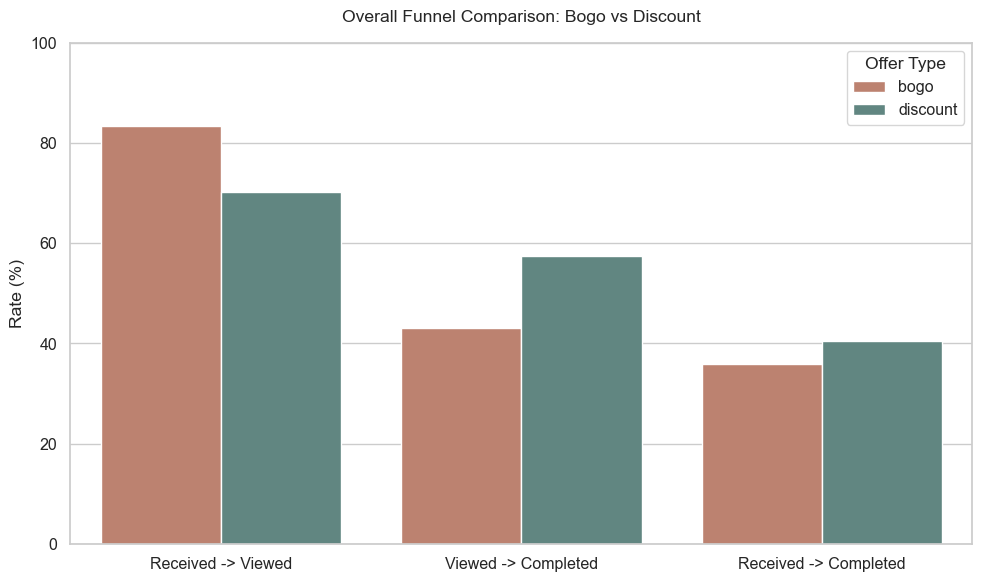

In [16]:
# 1) 공통 스타일 + 전체 퍼널 비교

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", font_scale=1.05)

# 한글 폰트가 깨지면 아래를 상황에 맞게 조정
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 6)

funnel_summary = seg_df.groupby('offer_type').agg(
    total_offers=('person', 'count'),
    viewed=('viewed_flag', 'sum'),
    completed=('completed_after_view_flag', 'sum')
).reset_index()

funnel_summary['열람율(%)'] = (funnel_summary['viewed'] / funnel_summary['total_offers'] * 100).round(1)
funnel_summary['단계별전환율(%)'] = (funnel_summary['completed'] / funnel_summary['viewed'] * 100).round(1)
funnel_summary['완료율(%)'] = (funnel_summary['completed'] / funnel_summary['total_offers'] * 100).round(1)

funnel_long = funnel_summary.melt(
    id_vars='offer_type',
    value_vars=['열람율(%)', '단계별전환율(%)', '완료율(%)'],
    var_name='stage',
    value_name='rate'
)

stage_order = ['열람율(%)', '단계별전환율(%)', '완료율(%)']
stage_labels = {
    '열람율(%)': 'Received -> Viewed',
    '단계별전환율(%)': 'Viewed -> Completed',
    '완료율(%)': 'Received -> Completed'
}

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=funnel_long,
    x='stage',
    y='rate',
    hue='offer_type',
    order=stage_order,
    palette=['#C97B63', '#5B8C85']
)

ax.set_title('Overall Funnel Comparison: Bogo vs Discount', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Rate (%)')
ax.set_xticklabels([stage_labels[s] for s in stage_order])
ax.legend(title='Offer Type')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


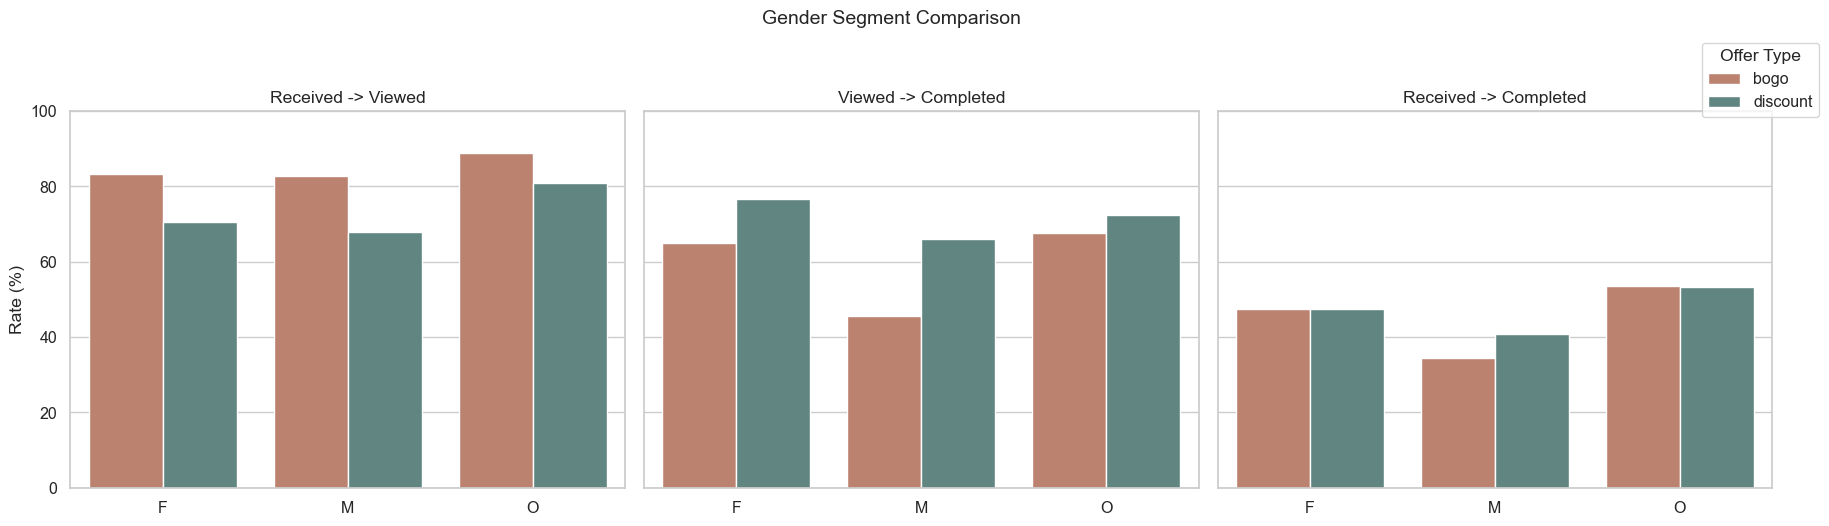

In [17]:
# 2) 성별 비교

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

metrics = ['열람율(%)', '단계별전환율(%)', '완료율(%)']
titles = ['Received -> Viewed', 'Viewed -> Completed', 'Received -> Completed']
palette = ['#C97B63', '#5B8C85']

for ax, metric, title in zip(axes, metrics, titles):
    sns.barplot(
        data=offer_type_gender,
        x='gender',
        y=metric,
        hue='offer_type',
        palette=palette,
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('Rate (%)' if ax == axes[0] else '')
    ax.set_ylim(0, 100)
    ax.legend_.remove()

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, title='Offer Type', loc='upper right', bbox_to_anchor=(1.02, 1))
fig.suptitle('Gender Segment Comparison', y=1.05, fontsize=14)
plt.tight_layout()
plt.show()


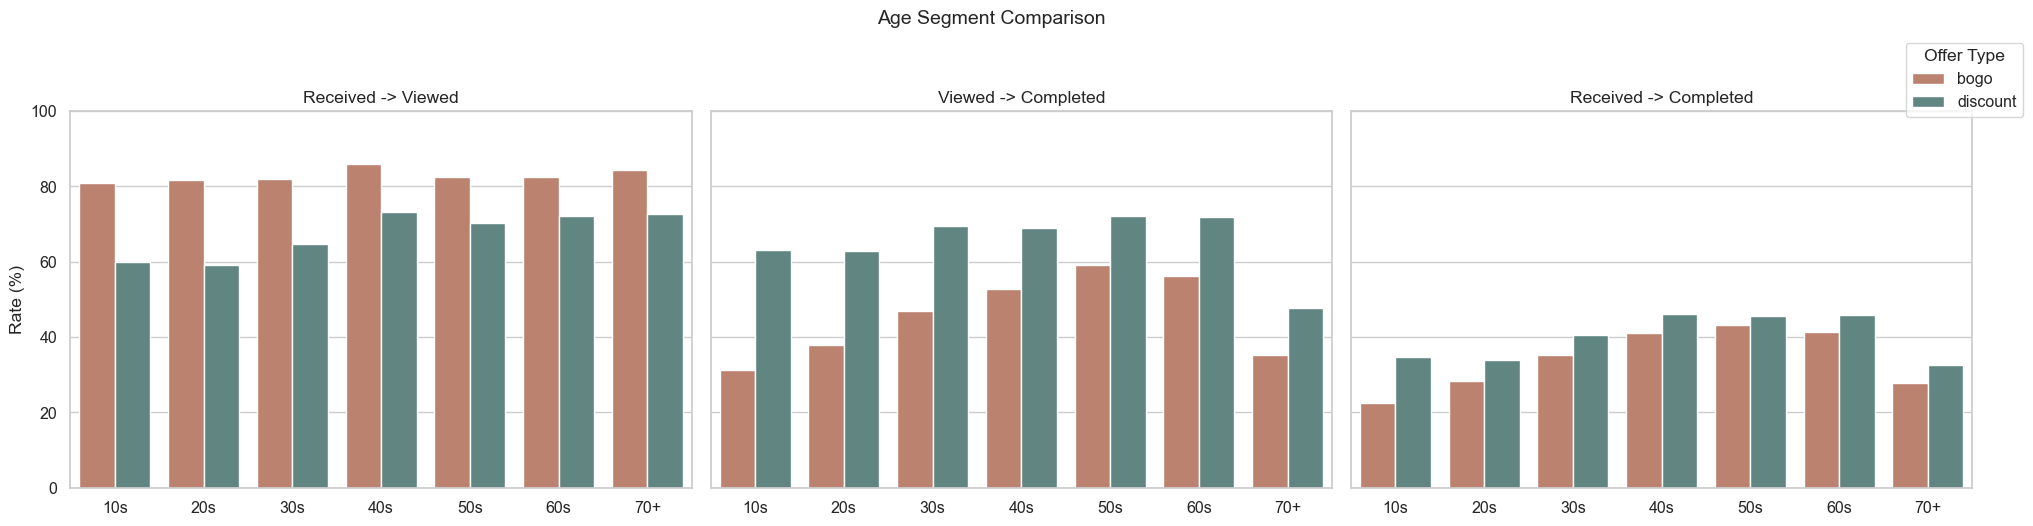

In [18]:
# 3) 연령대 비교

fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

metrics = ['열람율(%)', '단계별전환율(%)', '완료율(%)']
titles = ['Received -> Viewed', 'Viewed -> Completed', 'Received -> Completed']
palette = ['#C97B63', '#5B8C85']

for ax, metric, title in zip(axes, metrics, titles):
    sns.barplot(
        data=offer_type_age,
        x='age_group',
        y=metric,
        hue='offer_type',
        palette=palette,
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('Rate (%)' if ax == axes[0] else '')
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=0)
    ax.legend_.remove()

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, title='Offer Type', loc='upper right', bbox_to_anchor=(1.02, 1))
fig.suptitle('Age Segment Comparison', y=1.05, fontsize=14)
plt.tight_layout()
plt.show()


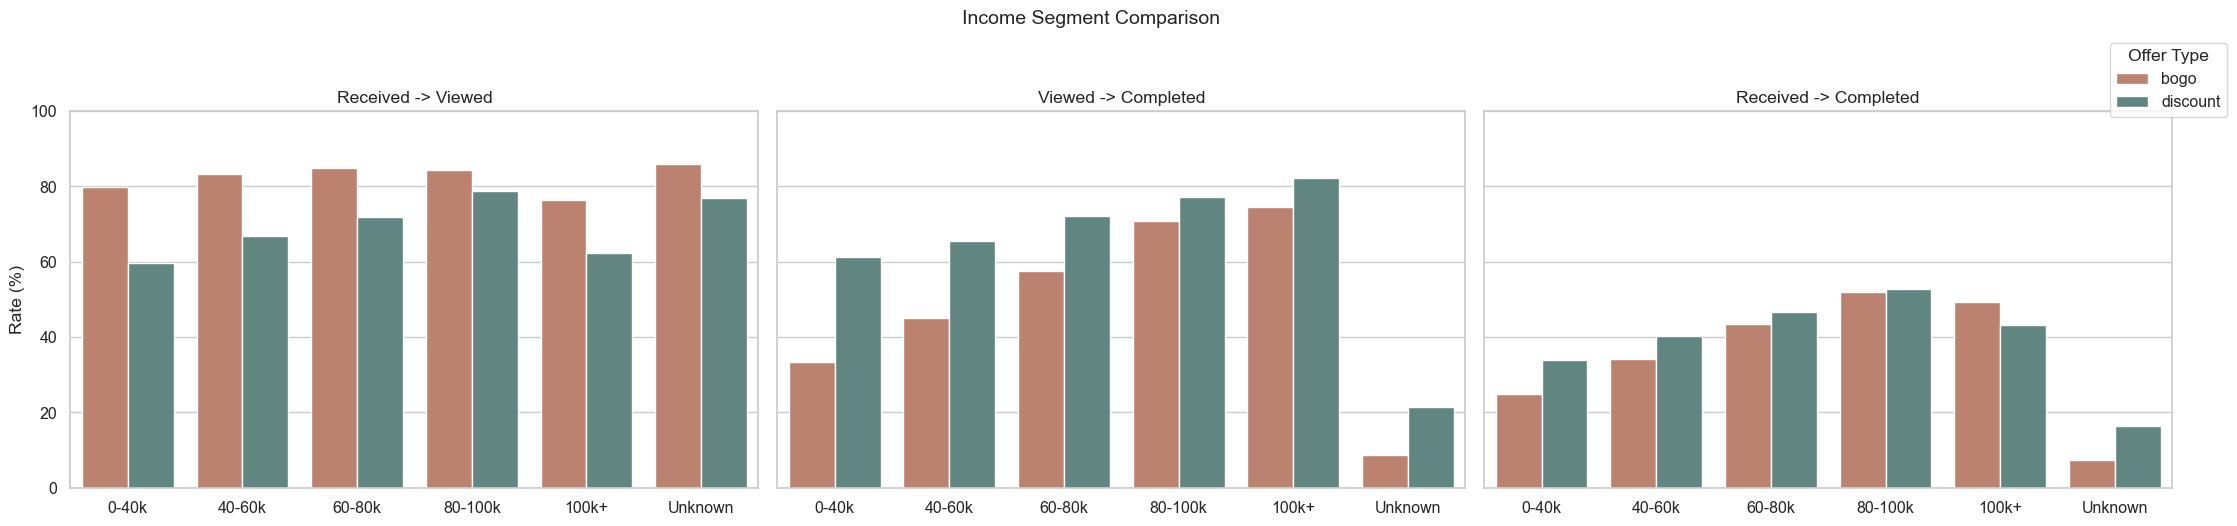

In [19]:
# 4) 소득대 비교

income_order = ['0-40k', '40-60k', '60-80k', '80-100k', '100k+', 'Unknown']

offer_type_income_plot = offer_type_income.copy()
offer_type_income_plot['income_group'] = pd.Categorical(
    offer_type_income_plot['income_group'],
    categories=income_order,
    ordered=True
)
offer_type_income_plot = offer_type_income_plot.sort_values('income_group')

fig, axes = plt.subplots(1, 3, figsize=(22, 5), sharey=True)

metrics = ['열람율(%)', '단계별전환율(%)', '완료율(%)']
titles = ['Received -> Viewed', 'Viewed -> Completed', 'Received -> Completed']
palette = ['#C97B63', '#5B8C85']

for ax, metric, title in zip(axes, metrics, titles):
    sns.barplot(
        data=offer_type_income_plot,
        x='income_group',
        y=metric,
        hue='offer_type',
        palette=palette,
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('Rate (%)' if ax == axes[0] else '')
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=0)
    ax.legend_.remove()

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, title='Offer Type', loc='upper right', bbox_to_anchor=(1.02, 1))
fig.suptitle('Income Segment Comparison', y=1.05, fontsize=14)
plt.tight_layout()
plt.show()


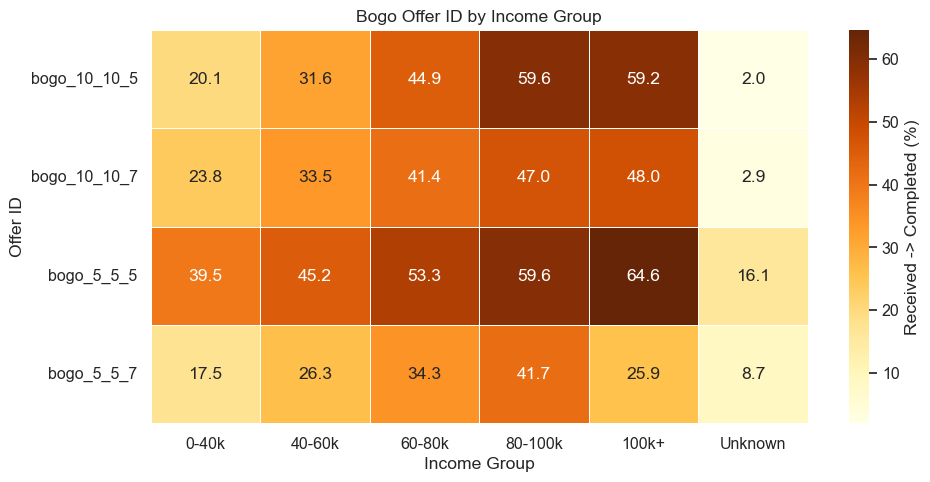

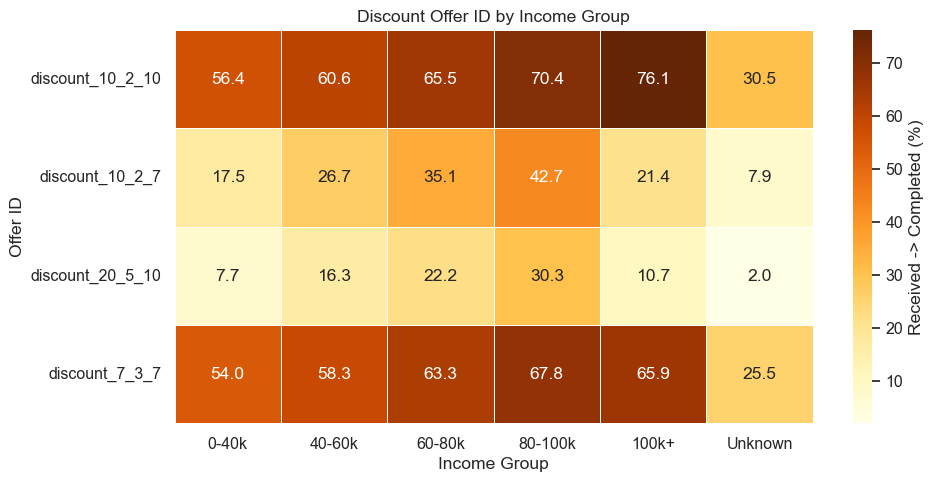

In [20]:
# 5) offer_id 보조 시각화: 히트맵

# offer_id_income에는 offer_id, income_group, 완료율(%)가 있어야 함
heatmap_df = offer_id_income.copy()

income_order = ['0-40k', '40-60k', '60-80k', '80-100k', '100k+', 'Unknown']
heatmap_df['income_group'] = pd.Categorical(
    heatmap_df['income_group'],
    categories=income_order,
    ordered=True
)

for offer_type in heatmap_df['offer_id'].str.split('_').str[0].unique():
    temp = heatmap_df[heatmap_df['offer_id'].str.startswith(offer_type)].copy()
    pivot = temp.pivot(index='offer_id', columns='income_group', values='완료율(%)')
    pivot = pivot[income_order]

    plt.figure(figsize=(10, 5))
    sns.heatmap(
        pivot,
        annot=True,
        fmt='.1f',
        cmap='YlOrBr',
        linewidths=0.5,
        cbar_kws={'label': 'Received -> Completed (%)'}
    )
    plt.title(f'{offer_type.capitalize()} Offer ID by Income Group')
    plt.xlabel('Income Group')
    plt.ylabel('Offer ID')
    plt.tight_layout()
    plt.show()
